# Raw plotting dev
VR 2025-09-05

In [1]:
import retinanalysis as ra
import numpy as np
import sys
import matplotlib.pyplot as plt
# sys.path.append('/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/src/retinanalysis/classes/')
# import raw
import importlib
# importlib.reload(raw)
import os

# ra.populate_database()
# ra.reload_celltypefiles(['20250814C'])

[2026-01-30 11:12:44,672][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


No NAS or SSD paths found, check that one of them is connected


In [2]:
exp_name = '20260113C'
ra.get_exp_summary(exp_name)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [2]:
ra.schema.Experiment().tail()

array([(160, 'dd6c5cf5-d4de-44b8-b1ed-4930fbb2cde1', '20250924C', '/Volumes/data-1/datajoint_testbed/mea/meta/20250924C.json', '/Volumes/data-1/data/h5/20250924C.h5', '/Volumes/data-1/datajoint_testbed/mea/tags/20250924C.json', 1, datetime.datetime(2025, 11, 18, 12, 53, 56), '20250924C', {'id': 'Z21227', 'age': '3yr 8mo', 'sex': 'male', 'weight': None, 'species': 'M. nemestrina', 'description': None, 'darkAdaptation': None}, {'uuid': 'dd6c5cf5-d4de-44b8-b1ed-4930fbb2cde1', 'label': '20250924C', 'creationTimeDotNetDateTimeOffsetTicks': 638943198922937643, 'creationTimeDotNetDateTimeOffsetOffsetHours': -7.0}, datetime.datetime(2025, 9, 24, 14, 11, 32), None, None, None, None, None, 'MEA'),
       (161, 'd7442cc1-ca70-47a0-bf85-13378f6a4f9c', '20251006C', '/Volumes/data-1/datajoint_testbed/mea/meta/20251006C.json', '/Volumes/data-1/data/h5/20251006C.h5', '/Volumes/data-1/datajoint_testbed/mea/tags/20251006C.json', 1, datetime.datetime(2025, 11, 18, 12, 54, 27), '20251006', {'id': 'Z21174'

In [3]:
ra.get_datasets_from_protocol_names('DovesMovie')


Found 2 protocols matching "dovesmovie":
['edu.washington.riekelab.turner.protocols.DovesMoviePlusLinearEquiv'
 'manookinlab.protocols.DovesMovie']

Found 46 experiments, 90 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20230614C,data007,0.0,chunk2,manookinlab.protocols.DovesMovie,1,20230614C/data007,doves,2,9,16,16,2
1,20230614C,data022,0.0,chunk3,manookinlab.protocols.DovesMovie,1,20230614C/data022,doves,2,9,30,31,4
2,20230719C,data008,0.0,chunk1,manookinlab.protocols.DovesMovie,1,20230719C/data008,doves repeats,5,9,72,79,7
3,20230719C,data028,0.0,chunk3,manookinlab.protocols.DovesMovie,1,20230719C/data028,doves repeats,5,9,86,98,9
4,20220909C,data012,NaN,chunk1,manookinlab.protocols.DovesMovie,1,20220909C/data012,Doves 4.0 ndf,23,9,334,790,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,20250529C,data019,0.5,doves,manookinlab.protocols.DovesMovie,1,20250529C/data019,Doves 4 R*,126,9,2279,3292,503
86,20250626H,data005,2.0,doves1,manookinlab.protocols.DovesMovie,1,20250626H/data005,Doves Repeats 3 R*,128,9,2289,3304,511
87,20251008H,data006,1.0,doves,manookinlab.protocols.DovesMovie,1,20251008H/data006,Doves,163,9,2622,3964,679
88,20251124C,data018,0.5,doves,manookinlab.protocols.DovesMovie,1,20251124C/data018,doves repeats,179,9,2754,4177,765


In [4]:
exp_name = '20251215C'
datafile_name = 'data004'
e_idx = 0
sb = ra.MEAStimBlock(exp_name, datafile_name)

Initializing StimBlock for 20251215C block 4246
Warning, none of the noise chunks in this experiment have typing files, chunk3 is None



In [5]:
sb.df_epochs

,epoch_index,subjectName,stimulusIndex,imageName,backgroundIntensity,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,ACB2.eye,2.0,imk00031.iml,0.353622,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283029
1,1,ABT2.eye,6.0,imk00034.iml,0.164178,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283030
2,2,ACB2.eye,12.0,imk00037.iml,0.152617,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283031
3,3,CLM2.eye,15.0,imk00037.iml,0.152617,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283032
4,4,ACB2.eye,18.0,imk00047.iml,0.183976,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,85,ACB2.eye,18.0,imk00047.iml,0.183976,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283114
86,86,AV2.eye,24.0,imk00053.iml,0.230272,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283115
87,87,BSQ2.eye,30.0,imk00054.iml,0.285867,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283116
88,88,CS2.eye,40.0,imk00060.iml,0.144705,20251215C,data004,doves repeats,manookinlab.protocols.DovesMovie,"[0.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0, 115....","{'NDF': 1.0, 'amp': 'Amp1', 'gain': None, 'ndf...",20251215C/data004,250.0,6000.0,500.0,183,2801,4246,9,283117


In [4]:
ra.get_df_dict_vals(sb.df_epochs, 'stixelSize')

array([90., 90., 90., 90., 90., 90., 90., 90., 90., 90., 90., 90., 90.,
       90., 90., 90.])

In [3]:
df = ra.get_datasets_from_protocol_names('manookinlab.protocols.DovesMovie', b_exact_match=True)


Found 43 experiments, 87 epoch blocks.



In [4]:
df

,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20230614C,data007,0.0,chunk2,manookinlab.protocols.DovesMovie,1,20230614C/data007,doves,2,9,16,16,2
1,20230614C,data022,0.0,chunk3,manookinlab.protocols.DovesMovie,1,20230614C/data022,doves,2,9,30,31,4
2,20230719C,data008,0.0,chunk1,manookinlab.protocols.DovesMovie,1,20230719C/data008,doves repeats,5,9,72,79,7
3,20230719C,data028,0.0,chunk3,manookinlab.protocols.DovesMovie,1,20230719C/data028,doves repeats,5,9,86,98,9
4,20220909C,data012,NaN,chunk1,manookinlab.protocols.DovesMovie,1,20220909C/data012,Doves 4.0 ndf,23,9,334,790,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,20250307C,data006,0.0,doves,manookinlab.protocols.DovesMovie,1,20250307C/data006,Doves Movies,120,9,2177,3169,468
83,20250529C,data013,4.0,doves,manookinlab.protocols.DovesMovie,1,20250529C/data013,Doves 10 R*,126,9,2273,3286,503
84,20250529C,data016,0.0,doves,manookinlab.protocols.DovesMovie,1,20250529C/data016,Doves Repeats 140 R*,126,9,2276,3289,503
85,20250529C,data019,0.5,doves,manookinlab.protocols.DovesMovie,1,20250529C/data019,Doves 4 R*,126,9,2279,3292,503


In [6]:
s = ra.MEAStimBlock('20250529C', 'data013')

Initializing StimBlock for 20250529C block 3286
Nearest noise chunk for data013 is chunk2 with distance 34 minutes.



In [20]:
s.d_epoch_block_params['stimulusIndices']

[2.0, 6.0, 12.0, 15.0, 18.0, 24.0, 30.0, 40.0, 50.0]

In [21]:
[int(idx) for idx in s.d_epoch_block_params['stimulusIndices']]

[2, 6, 12, 15, 18, 24, 30, 40, 50]

Check cell 420 and 444 for 20250814C data019 duplicates

Method 1 (Phy): get best channels for given cluster from kilosort templates info

In [6]:
# str_templates = '/Volumes/Vyom MEA/analysis/20250306C/data026/kilosort2.5/templates.npy'
# str_templates = '/Volumes/data-1/data/sorted/20250814C/data019/kilosort2.5/templates.npy'
ks_dir = '/Users/riekelabbackup/Desktop/Vyom/data/analysis/20250306C/data026/kilosort2.5'
str_templates = os.path.join(ks_dir, 'templates.npy')
str_channel_positions = os.path.join(ks_dir, 'channel_positions.npy')
templates = np.load(str_templates)
channel_positions = np.load(str_channel_positions)
print(templates.shape)  # (n_templates, n_timepoints, n_channels)

(1722, 82, 512)


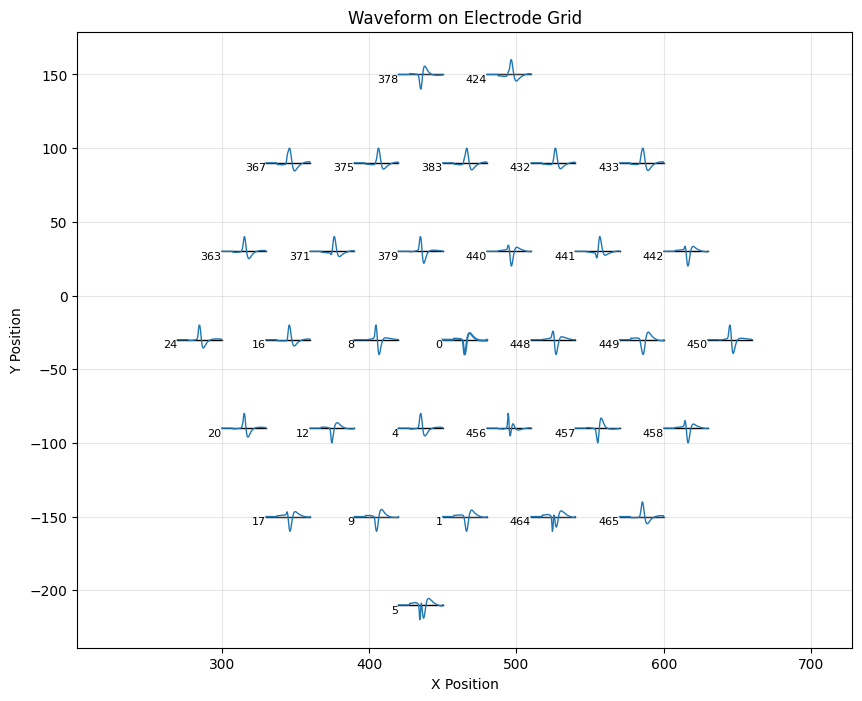

In [31]:
def plot_waveform_on_grid(
        template, channel_positions, wf_scale=1.0, 
        t_scale=1.0,
        color='C0', amplitude_threshold=0.05):
    """
    Plot a template (n_timepoints, n_channels) on a grid using channel_positions (n_channels, 2).
    Each waveform is plotted at its (x, y) position.
    """
    n_timepoints, n_channels = template.shape
    amplitudes = template.max(axis=0) - template.min(axis=0)
    best_channel = np.argmax(amplitudes)
    max_amp = amplitudes[best_channel]
    # Only plot channels with significant amplitude
    peak_channels = np.where(amplitudes > amplitude_threshold * max_amp)[0]

    # Normalize waveforms for display
    t = np.arange(n_timepoints)
    t = t - t.mean()
    t = t / t.max()  # scale time to [-1, 1]
    t = t * t_scale  # scale time axis

    plt.figure(figsize=(10, 8))
    for ch in peak_channels:
        x, y = channel_positions[ch]
        wf = template[:, ch]
        wf = wf / np.max(np.abs(wf)) * wf_scale  # normalize amplitude
        # Offset waveform to (x, y)
        if ch==best_channel:
            lw=1.5
        else:
            lw=1
        plt.plot(x + t, y + wf, color=color, lw=lw)
        # plt.scatter([x], [y], color='r', s=10, zorder=3)  # mark channel center
        # Hline at zero
        plt.plot([x - t_scale, x + t_scale], [y, y], color='k', lw=1, ls='-', zorder=1)
        # Electrode number at x-t_scale, y
        plt.text(x - t_scale, y, str(ch), color='k', fontsize=8, ha='right', va='top')

    plt.title('Waveform on Electrode Grid')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage:
plot_waveform_on_grid(templates[0], channel_positions, wf_scale=10, t_scale=15, amplitude_threshold=0.0)

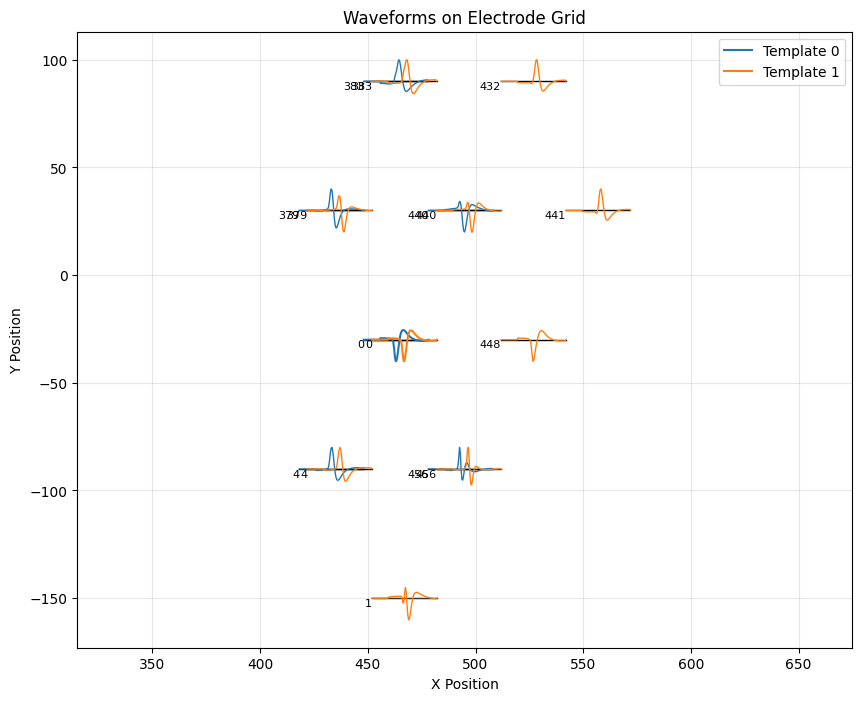

In [40]:
def plot_waveforms_on_grid(
    templates, channel_positions, wf_scale=1.0, t_scale=1.0, amplitude_threshold=0.05, 
    overlap=True, colors=None, offset_frac=0.25
):
    """
    Plot multiple templates (n_templates, n_timepoints, n_channels) on a grid using channel_positions (n_channels, 2).
    If overlap is False, waveforms are offset horizontally at each channel.
    """
    n_templates, n_timepoints, n_channels = templates.shape
    if colors is None:
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(n_templates)]

    t = np.arange(n_timepoints)
    t = t - t.mean()
    t = t / t.max()  # scale time to [-1, 1]
    t = t * t_scale  # scale time axis

    plt.figure(figsize=(10, 8))
    for i in range(n_templates):
        template = templates[i]
        amplitudes = template.max(axis=0) - template.min(axis=0)
        best_channel = np.argmax(amplitudes)
        max_amp = amplitudes[best_channel]
        peak_channels = np.where(amplitudes > amplitude_threshold * max_amp)[0]
        color = colors[i]

        for j, ch in enumerate(peak_channels):
            x, y = channel_positions[ch]
            wf = template[:, ch]
            wf = wf / np.max(np.abs(wf)) * wf_scale  # normalize amplitude

            # Offset for non-overlap
            if overlap:
                x_offset = 0
            else:
                # Offset each template at this channel horizontally
                x_offset = (i - (n_templates-1)/2) * offset_frac * t_scale

            lw = 1.5 if ch == best_channel else 1
            plt.plot(x + t + x_offset, y + wf, color=color, lw=lw, label=f'Template {i}' if (j==0 and ch==peak_channels[0]) else None)
            plt.plot([x - t_scale + x_offset, x + t_scale + x_offset], [y, y], color='k', lw=1, ls='-', zorder=1)
            plt.text(x - t_scale + x_offset, y, str(ch), color='k', fontsize=8, ha='right', va='top')

    plt.title('Waveforms on Electrode Grid')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    # Only show one legend entry per template
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())
    plt.show()

# Example usage:
plot_waveforms_on_grid(templates[[0,1]], channel_positions, wf_scale=10, t_scale=15, amplitude_threshold=0.1, overlap=False)

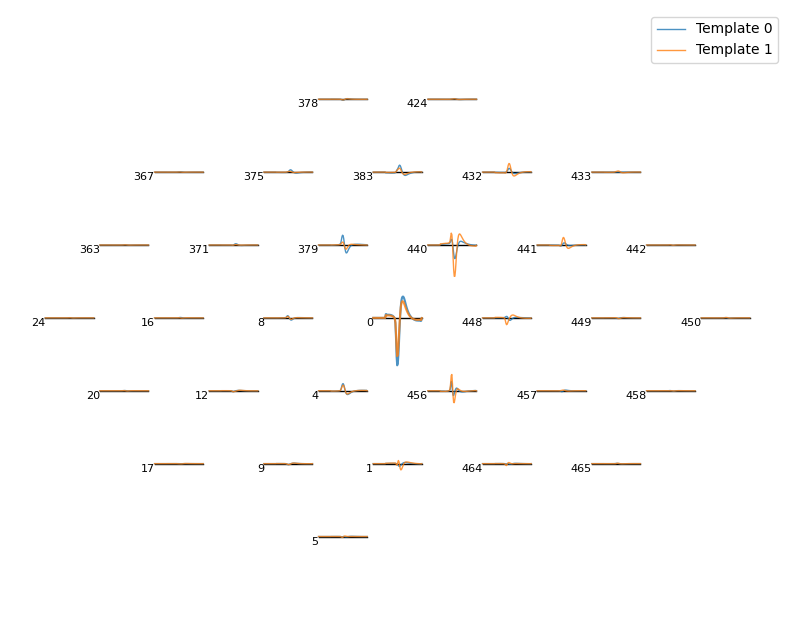

In [85]:
def plot_waveforms_on_grid(
    templates, channel_positions, wf_scale=1.0, t_scale=1.0, amplitude_threshold=0.00, 
    overlap=True, colors=None, x_ch_sep=1.0, y_ch_sep=1.0, wf_norm=False
):
    """
    Plot multiple templates (n_templates, n_timepoints, n_channels) on a grid using channel_positions (n_channels, 2).
    If overlap is False, waveforms are offset horizontally at each channel.
    Channel label and zero line are only drawn once per channel.
    """
    n_templates, n_timepoints, n_channels = templates.shape
    if colors is None:
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i % 10) for i in range(n_templates)]

    # Scale channel positions
    channel_positions = channel_positions.copy()
    channel_positions[:, 0] = channel_positions[:, 0] * x_ch_sep
    channel_positions[:, 1] = channel_positions[:, 1] * y_ch_sep

    t = np.arange(n_timepoints)
    t = t - t.mean()
    t = t / t.max()  # scale time to [-1, 1]
    t = t * t_scale  # scale time axis

    # For each channel, find which templates have significant amplitude
    channel_to_templates = {}
    for ch in range(n_channels):
        channel_to_templates[ch] = []
        for i in range(n_templates):
            template = templates[i]
            amplitudes = template.max(axis=0) - template.min(axis=0)
            best_channel = np.argmax(amplitudes)
            max_amp = amplitudes[best_channel]
            if amplitudes[ch] > amplitude_threshold * max_amp:
                channel_to_templates[ch].append(i)

    plt.figure(figsize=(10, 8))
    for ch in range(n_channels):
        templates_here = channel_to_templates[ch]
        n_here = len(templates_here)
        if n_here == 0:
            continue
        x, y = channel_positions[ch]
        # Draw zero line and label only once per channel
        plt.plot([x - t_scale, x + t_scale], [y, y], color='k', lw=1, ls='-', zorder=1)
        plt.text(x - t_scale, y, str(ch), color='k', fontsize=8, ha='right', va='top')
        for idx, i in enumerate(templates_here):
            template = templates[i]
            wf = template[:, ch]
            if wf_norm:
                wf = wf / np.max(np.abs(wf))  # normalize amplitude
            wf = wf  * wf_scale  # scale
            # Offset for non-overlap
            if overlap or n_here == 1:
                x_offset = 0
                opacity = 0.8
            else:
                # Center the offsets around zero
                x_offset = ((idx - (n_here-1)/2) * t_scale)*2
                opacity = 1.0
            amplitudes = template.max(axis=0) - template.min(axis=0)
            best_channel = np.argmax(amplitudes)
            lw = 1.5 if ch == best_channel else 1
            plt.plot(x + t + x_offset, y + wf, color=colors[i], lw=lw, alpha=opacity,
                     label=f'Template {i}')

    # plt.title('Waveforms on Electrode Grid')
    # plt.xlabel('X Position')
    # plt.ylabel('Y Position')
    plt.axis('equal')
    plt.axis('off')
    plt.grid(True, alpha=0.3)
    # Only show one legend entry per template
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())
    plt.show()

# Example usage:
plot_waveforms_on_grid(
    templates[[0,1]], channel_positions, wf_scale=100, t_scale=20, 
    amplitude_threshold=0, overlap=True, x_ch_sep=1.5, wf_norm=False)

In [6]:
def get_best_channels_phy(templates):
    # Check if nan in any templates
    broken_templates = np.where(np.isnan(templates).sum(axis=(1,2)))[0]
    if np.any(broken_templates):
        print(f"Warning: {len(broken_templates)} templates contain NaN values. These will be skipped.")
        print(f"Broken templates indices: {broken_templates}")

    # Amplitudes of shape (n_templates, n_channels)
    amplitudes = templates.max(axis=1) - templates.min(axis=1)
    # print(amplitudes.shape)
    max_channels = np.argmax(amplitudes, axis=1)
    # print(max_channels.shape)
    max_amps = np.max(amplitudes, axis=1)
    # print(max_amps.shape)

    amplitude_threshold = 0
    # peak_channels = np.where(amplitudes > amplitude_threshold * max_amps)
    # Make array of (templates, X) where X is number of channels above threshold
    # X is constant for KS2, typically 32
    n_peak_channels = np.where(amplitudes[0] > amplitude_threshold * max_amps[0])[0].shape[0]
    
    peak_channels = np.zeros((templates.shape[0], n_peak_channels), dtype=int)
    for i in range(templates.shape[0]):
        if i in broken_templates:
            peak_channels[i, :] = -1
        else:
            peak_channels[i, :] = np.where(amplitudes[i] > amplitude_threshold * max_amps[i])[0]

    return peak_channels

def get_channel_cluster_dict(templates):
    best_channels = get_best_channels_phy(templates)
    d_channel_clusters = {}
    for cell_id in range(best_channels.shape[0]):
        for ch in best_channels[cell_id]:
            if ch not in d_channel_clusters:
                d_channel_clusters[ch] = []
            d_channel_clusters[ch].append(cell_id)
    return d_channel_clusters

# best_channels = get_best_channels_phy(templates)
d_chc = get_channel_cluster_dict(templates)

In [85]:
d_chc[222]

[440,
 441,
 442,
 443,
 444,
 445,
 456,
 457,
 458,
 459,
 460,
 461,
 462,
 470,
 471,
 472,
 473,
 474,
 475,
 476,
 477,
 478,
 479,
 480,
 481,
 482,
 483,
 484,
 485,
 486,
 491,
 492,
 493,
 494,
 495,
 496,
 497,
 498,
 499,
 500,
 501,
 502,
 503,
 504,
 505,
 506,
 507,
 517,
 518,
 519,
 520,
 521,
 522,
 523,
 524,
 525,
 534,
 537,
 538,
 539,
 540,
 541,
 542,
 543,
 544,
 557,
 558,
 559,
 560,
 561,
 562,
 563,
 564,
 565,
 568,
 569,
 570,
 1324,
 1325,
 1326,
 1330,
 1335,
 1336,
 1337,
 1345,
 1346,
 1347,
 1351,
 1352,
 1353,
 1354,
 1355,
 1356,
 1624,
 1625,
 1628,
 1629,
 1630,
 1633,
 1634,
 1635,
 1636]

Best channel: 207
Peak channels: [112 120 124 183 189 190 191 197 198 199 204 205 206 207 213 214 215 221
 222 223 231 258 259 262 263 266 267 270 271 274 275 279]
32
Best channel: 195
Peak channels: [170 171 177 178 179 180 181 184 185 186 187 188 189 192 193 194 195 196
 197 198 200 201 202 203 204 205 209 210 211 212 213 218]
32


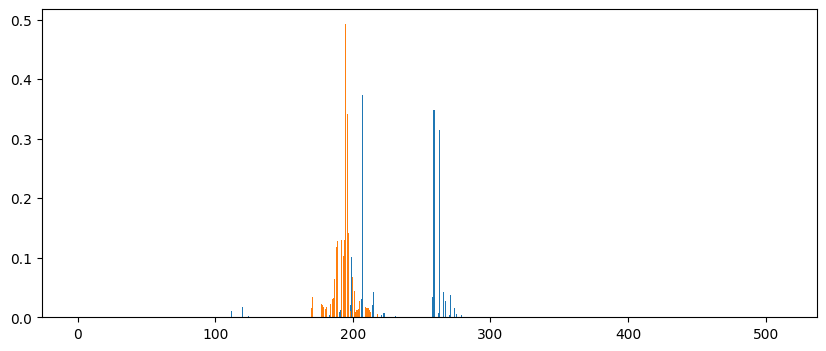

In [ ]:
plt.figure(figsize=(10, 4))
def plot_amp_for_cell(cell_id):
    template = templates[cell_id]  # shape (n_timepoints, n_channels)
    amplitudes = template.max(axis=0) - template.min(axis=0)
    best_channel = np.argmax(amplitudes)
    max_amp = amplitudes[best_channel]

    amplitude_threshold = 0
    peak_channels = np.nonzero(amplitudes > amplitude_threshold * max_amp)[0]

    print(f"Best channel: {best_channel}")
    print(f"Peak channels: {peak_channels}")
    # order = np.argsort(amplitudes)[::-1]
    # Plot amplitudes and cutoff
    
    plt.bar(np.arange(len(amplitudes)), amplitudes)#[order])
    print(len(peak_channels))
    # plt.scatter(best_channel, amplitude[best_channel], color='red', label='Best Channel')
    # plt.imshow(template.T, aspect='auto', cmap='bwr')
    # plt.colorbar(label='Amplitude')
plot_amp_for_cell(419)
plot_amp_for_cell(443)

Best channel: 207
Peak channels: [112 120 124 183 189 190 191 197 198 199 204 205 206 207 213 214 215 221
 222 223 231 258 259 262 263 266 267 270 271 274 275 279]
32


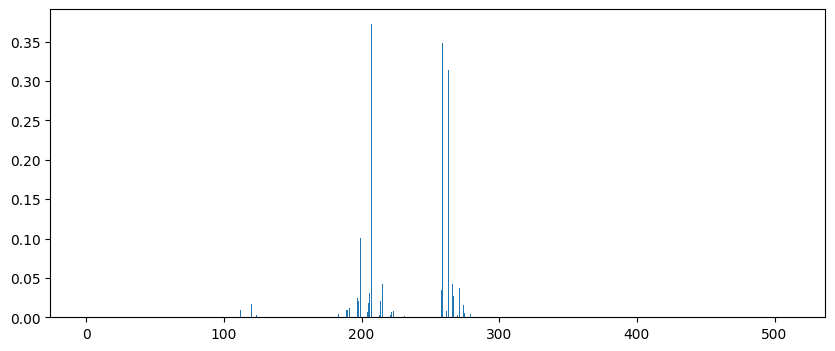

In [11]:
cell_id = 443#419#470 # example cell id
template = templates[cell_id]  # shape (n_timepoints, n_channels)
amplitudes = template.max(axis=0) - template.min(axis=0)
best_channel = np.argmax(amplitudes)
max_amp = amplitudes[best_channel]

amplitude_threshold = 0
peak_channels = np.nonzero(amplitudes > amplitude_threshold * max_amp)[0]

print(f"Best channel: {best_channel}")
print(f"Peak channels: {peak_channels}")
# order = np.argsort(amplitudes)[::-1]
# Plot amplitudes and cutoff
plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(amplitudes)), amplitudes)#[order])
print(len(peak_channels))
# plt.scatter(best_channel, amplitude[best_channel], color='red', label='Best Channel')
# plt.imshow(template.T, aspect='auto', cmap='bwr')
# plt.colorbar(label='Amplitude')